# প্রকল্প ০২: খাবারের শ্রেণীবিভাগ
## 🍜 র‍্যান্ডম ফরেস্ট + লজিস্টিক রিগ্রেশন

### 🎪 গল্প দিয়ে শুরু করি

**মনে করো,** তুমি একজন শেফ। তুমি রান্নাঘরে দাঁড়িয়ে উপকরণ দেখছো — রসুন, পেঁয়াজ, টমেটো, মরিচ...

তুমি কি বলতে পারবে এই উপকরণ দিয়ে কোন দেশের খাবার বানানো হবে?
- যদি দেখো **রসুন, তেল, লেবু** → তাহলে সম্ভবত **ভূমধ্যসাগরীয়**
- যদি দেখো **সয়া সস, আদা, চালের ভিনেগার** → তাহলে সম্ভবত **জাপানি**

**ঠিক এটাই আমরা মেশিনকে শেখাবো!** আমরা বিভিন্ন দেশের খাবারের উপকরণের তালিকা দিয়ে মেশিনকে প্রশিক্ষণ দেবো, যাতে সে নতুন উপকরণ দেখে বলতে পারে — এটা কোন দেশের খাবার!

## 📂 ডেটা লোড ও এক্সপ্লোরেশন

In [1]:
# লাইব্রেরি ইম্পোর্ট করছি
import pandas as pd  # ডেটা নিয়ে কাজ করার জন্য
import numpy as np  # গণিতের জন্য
import matplotlib.pyplot as plt  # গ্রাফের জন্য
import seaborn as sns  # সুন্দর গ্রাফের জন্য
from sklearn.model_selection import train_test_split  # ডেটা ভাগ করার জন্য
from sklearn.feature_extraction.text import CountVectorizer  # টেক্সট থেকে ফিচার বানানোর জন্য
from sklearn.linear_model import LogisticRegression  # লজিস্টিক রিগ্রেশন
from sklearn.ensemble import RandomForestClassifier  # র‍্যান্ডম ফরেস্ট
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score  # মূল্যায়ন

# ডেটা লোড
df = pd.read_csv('cuisines.csv')
print('ডেটার প্রথম ৫ সারি:')
display(df.head())
print(f'\nমোট রেসিপি: {len(df)}')


ডেটার প্রথম ৫ সারি:


,cuisine,ingredients
0,Mediterranean,"shrimp,garlic,butter,lemon,rice,parsley"
1,European,"fish,lemon,butter,garlic,potato,parsley"
2,Mediterranean,"shrimp,garlic,butter,lemon,rice,parsley"
3,Mediterranean,"shrimp,garlic,butter,lemon,rice,parsley"
4,Japanese,"tofu,vegetables,soy_sauce,ginger,rice,noodles"



মোট রেসিপি: 550


In [2]:
# ডেটার বিভিন্ন তথ্য দেখা যাক
print('=== দেশ অনুযায়ী রেসিপির সংখ্যা ===')
print(df['cuisine'].value_counts())
print(f'\nমোট দেশের সংখ্যা: {df["cuisine"].nunique()}')

# দেশগুলোর নাম
print('\nদেশগুলোর নাম:')
for i, cuisine in enumerate(df['cuisine'].unique(), 1):
    print(f'{i}. {cuisine}')

=== দেশ অনুযায়ী রেসিপির সংখ্যা ===
cuisine
Japanese          59
French            57
Mediterranean     56
Chinese           55
Indian            55
Italian           54
Middle-Eastern    54
Thai              54
European          53
Korean            53
Name: count, dtype: int64

মোট দেশের সংখ্যা: 10

দেশগুলোর নাম:
1. Mediterranean
2. European
3. Japanese
4. Italian
5. Korean
6. Chinese
7. French
8. Middle-Eastern
9. Thai
10. Indian


## 🔧 ডেটা প্রস্তুত করা
উপকরণগুলোকে কম্পিউটার বোঝার মতো সংখ্যায় রূপান্তর করতে হবে। আমরা `CountVectorizer` ব্যবহার করবো — প্রতিটি উপকরণকে আলাদা ফিচার বানাবে।

In [3]:
# ফিচার (X) এবং টার্গেট (y) নির্ধারণ
X = df['ingredients']  # উপকরণের তালিকা (টেক্সট)
y = df['cuisine']  # দেশের নাম

# টেক্সট ডেটাকে সংখ্যায় রূপান্তর
vectorizer = CountVectorizer()  # টেক্সট ভেক্টরাইজার
X_vec = vectorizer.fit_transform(X)  # উপকরণকে সংখ্যায় বদলানো

print(f'ফিচারের মোট সংখ্যা: {X_vec.shape[1]}')
print(f'প্রথম কিছু উপকরণ (ফিচার): {list(vectorizer.get_feature_names_out()[:10])}')

# ডেটা ভাগ করা
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42, stratify=y)
print(f'\nট্রেন ডেটা: {X_train.shape[0]}টি, টেস্ট ডেটা: {X_test.shape[0]}টি')

ফিচারের মোট সংখ্যা: 35
প্রথম কিছু উপকরণ (ফিচার): ['beef', 'butter', 'cheese', 'chicken', 'chilli', 'coconut_milk', 'cream', 'cumin', 'curry_paste', 'fish']

ট্রেন ডেটা: 440টি, টেস্ট ডেটা: 110টি


## 🤖 লজিস্টিক রিগ্রেশন
লজিস্টিক রিগ্রেশন — যদিও নামে "রিগ্রেশন", কিন্তু এটি ক্লাসিফিকেশনের জন্য ব্যবহার করা হয়!

In [4]:
# লজিস্টিক রিগ্রেশন মডেল
lr_model = LogisticRegression(max_iter=1000, random_state=42)  # মডেল তৈরি
lr_model.fit(X_train, y_train)  # মডেল শেখানো

# পূর্বাভাস
y_pred_lr = lr_model.predict(X_test)

# ফলাফল
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'🔵 লজিস্টিক রিগ্রেশন নির্ভুলতা: {acc_lr:.4f} ({acc_lr*100:.2f}%)')
print('\n=== ক্লাসিফিকেশন রিপোর্ট ===')
print(classification_report(y_test, y_pred_lr))

🔵 লজিস্টিক রিগ্রেশন নির্ভুলতা: 0.9636 (96.36%)

=== ক্লাসিফিকেশন রিপোর্ট ===
                precision    recall  f1-score   support

       Chinese       1.00      1.00      1.00        11
      European       1.00      1.00      1.00        11
        French       1.00      1.00      1.00        11
        Indian       1.00      0.91      0.95        11
       Italian       0.92      1.00      0.96        11
      Japanese       0.92      1.00      0.96        12
        Korean       0.89      0.80      0.84        10
 Mediterranean       1.00      1.00      1.00        11
Middle-Eastern       0.91      0.91      0.91        11
          Thai       1.00      1.00      1.00        11

      accuracy                           0.96       110
     macro avg       0.96      0.96      0.96       110
  weighted avg       0.96      0.96      0.96       110



C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWar

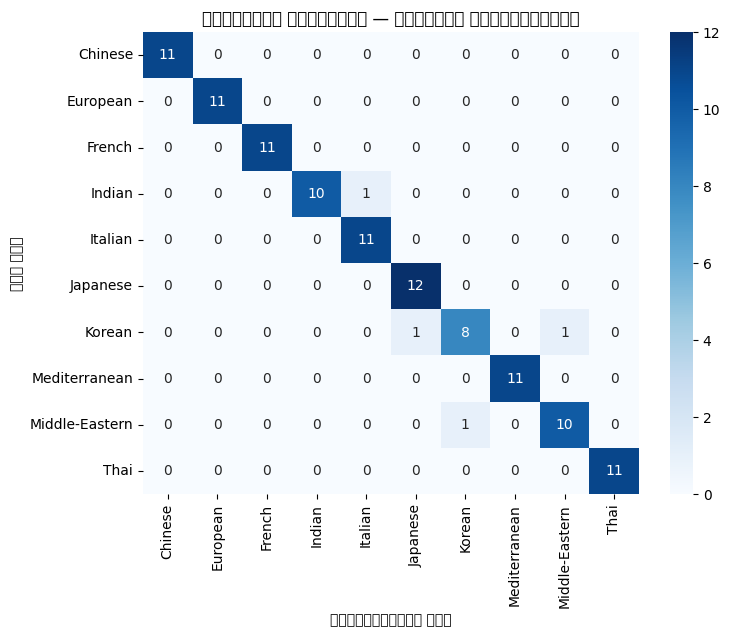

In [5]:
# লজিস্টিক রিগ্রেশন — কনফিউশন ম্যাট্রিক্স
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_model.classes_, yticklabels=lr_model.classes_)
plt.title('লজিস্টিক রিগ্রেশন — কনফিউশন ম্যাট্রিক্স')
plt.xlabel('পূর্বাভাসিত দেশ')
plt.ylabel('আসল দেশ')
plt.show()

## 🌳 র‍্যান্ডম ফরেস্ট ক্লাসিফায়ার
র‍্যান্ডম ফরেস্ট অনেকগুলো ডিসিশন ট্রি একসাথে ব্যবহার করে — ঠিক যেমন অনেক বন্ধু মিলে সিদ্ধান্ত নিলে ভুল হওয়ার সম্ভাবনা কম!

In [6]:
# র‍্যান্ডম ফরেস্ট মডেল
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # ১০০ টি ট্রি
rf_model.fit(X_train, y_train)  # শেখানো

# পূর্বাভাস
y_pred_rf = rf_model.predict(X_test)

# ফলাফল
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'🟢 র‍্যান্ডম ফরেস্ট নির্ভুলতা: {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print('\n=== ক্লাসিফিকেশন রিপোর্ট ===')
print(classification_report(y_test, y_pred_rf))

🟢 র‍্যান্ডম ফরেস্ট নির্ভুলতা: 0.9636 (96.36%)

=== ক্লাসিফিকেশন রিপোর্ট ===
                precision    recall  f1-score   support

       Chinese       1.00      1.00      1.00        11
      European       1.00      1.00      1.00        11
        French       1.00      1.00      1.00        11
        Indian       1.00      0.91      0.95        11
       Italian       0.92      1.00      0.96        11
      Japanese       0.92      1.00      0.96        12
        Korean       0.89      0.80      0.84        10
 Mediterranean       1.00      1.00      1.00        11
Middle-Eastern       0.91      0.91      0.91        11
          Thai       1.00      1.00      1.00        11

      accuracy                           0.96       110
     macro avg       0.96      0.96      0.96       110
  weighted avg       0.96      0.96      0.96       110



C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWar

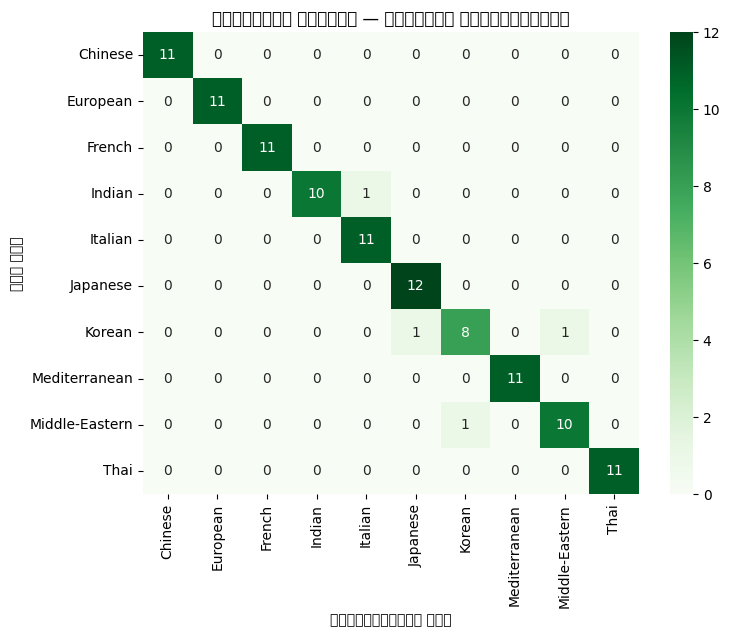

In [7]:
# র‍্যান্ডম ফরেস্ট — কনফিউশন ম্যাট্রিক্স
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('র‍্যান্ডম ফরেস্ট — কনফিউশন ম্যাট্রিক্স')
plt.xlabel('পূর্বাভাসিত দেশ')
plt.ylabel('আসল দেশ')
plt.show()

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2496 (\N{BENGALI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: Us

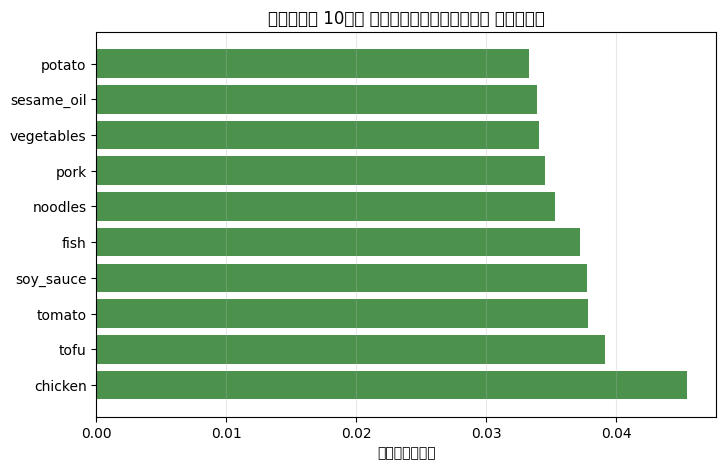

In [8]:
# সবচেয়ে গুরুত্বপূর্ণ উপকরণ দেখা যাক
feature_names = vectorizer.get_feature_names_out()
importances = rf_model.feature_importances_
top_n = 10
top_indices = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(8, 5))
plt.barh(range(top_n), importances[top_indices][::-1], color='darkgreen', alpha=0.7)
plt.yticks(range(top_n), [feature_names[i] for i in top_indices[::-1]])
plt.xlabel('গুরুত্ব')
plt.title(f'শীর্ষ {top_n}টি গুরুত্বপূর্ণ উপকরণ')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.show()

## 📊 তুলনা ও উপসংহার

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2477 (\N{BENGALI LETTER BHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtoo

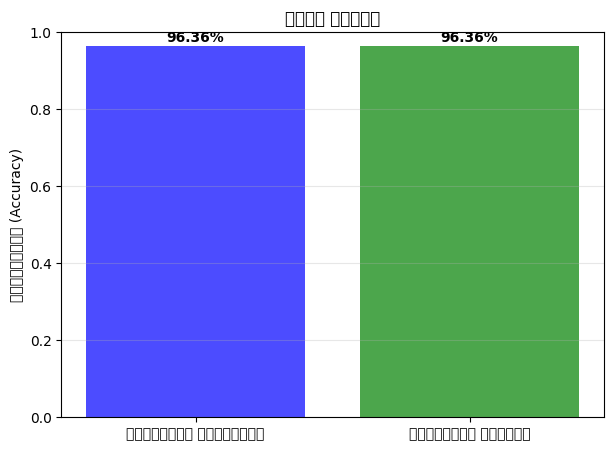


🏆 র‍্যান্ডম ফরেস্ট ভালো করেছে (96.36%)


In [9]:
# দুই মডেলের তুলনা
models = ['লজিস্টিক রিগ্রেশন', 'র‍্যান্ডম ফরেস্ট']
accuracies = [acc_lr, acc_rf]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=['blue', 'green'], alpha=0.7)
plt.ylim(0, 1)
plt.ylabel('নির্ভুলতা (Accuracy)')
plt.title('মডেল তুলনা')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

if acc_lr > acc_rf:
    print(f'\n🏆 লজিস্টিক রিগ্রেশন ভালো করেছে ({acc_lr:.2%})')
else:
    print(f'\n🏆 র‍্যান্ডম ফরেস্ট ভালো করেছে ({acc_rf:.2%})')

## 🎯 তুমি কি শিখলে?

| ধারণা | বাংলায় অর্থ |
|-------|-------------|
| **ক্লাসিফিকেশন** | জিনিসগুলোকে বিভিন্ন শ্রেণীতে ভাগ করা |
| **লজিস্টিক রিগ্রেশন** | সম্ভাবনা বের করে ক্লাসিফিকেশন করা |
| **র‍্যান্ডম ফরেস্ট** | অনেক গাছের মত সিদ্ধান্ত নেওয়া (বেশি নির্ভুল!) |
| **কনফিউশন ম্যাট্রিক্স** | মডেল কোথায় ভুল করছে তা দেখার ছক |
| **CountVectorizer** | টেক্সটকে সংখ্যায় রূপান্তর করার পদ্ধতি |

**মনে রাখবে:** মেশিন লার্নিং এ ডেটা প্রস্তুত করা সবচেয়ে গুরুত্বপূর্ণ অংশ! উপকরণের নামগুলোকে ঠিকভাবে সংখ্যায় রূপান্তর করাই এখানে মূল কাজ ছিল। 🍜